# Chapitre 4 : Du machine learning au deep learning pour la classification d'images 📊🧠

Dans ce cours, nous allons explorer les concepts fondamentaux de la classification d'images en utilisant des modèles de deep learning.
Nous allons utiliser la librairie tensorflow qui permet de créer des modèles de deep learning.

De plus nous ménerons une experience sur la différence de précision entre un modèle CNN et des modèles llm possèdant des attraits pour la classification d'images.

N'hésite pas à lire ces ressources ✅

- [Un cnn c'est quoi ?](https://fr.mathworks.com/discovery/convolutional-neural-network.html)
- [Avantages et applications en IA des cnn](https://www.innovatiana.com/post/convolutional-neural-network)
- [A Complete Guide to Image Classification in 2025](https://viso.ai/computer-vision/image-classification/)
- [Tutoriel sur la régression logistique](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [CNN Visualizer 🤯](https://poloclub.github.io/cnn-explainer/)
  
Si tu as des questions ! 🙌🏼 Lance-toi !

Durant cette masterclasse nous allons voir les points suivants :

- Comprendre le fonctionnement d'un modèle de deep learning
- Comprendre les concepts de base d'un CNN
- Entraîner un CNN pour la classification d'images
- Juger la performance d'un CNN



## Le deep learning ? Kesako ? 🤔

Dans le cours précedents, nous avons vu les concepts de base d'un modèle de machine learning.
Nous avons aussi compris les grands principes de fonctionnement d'un modèle. 

A ce stade, rien ne change. 

Un modèle de deep learning est un modèle de machine learning mais avec des **<span style="color:green">couches cachées</span>**. 

Ces **<span style="color:green">couches cachées</span>** permettent au modèle d'apprendre des représentations intermédiaires des données d'entrée.
Cela permet de capturer des informations plus complexes et abstraites, ce qui est crucial pour les tâches complexes comme la classification d'images.

Mais dans les faits, nous avons toujours: 
 - Une phase de data cleaning 🧹
 - Une phase de data exploration (moins importante pour le deep learning) 🔍
 - Une phase de data preprocessing 🔄
 - Une phase de model training 🏋️‍♂️
 - Une phase de model evaluation 📊
 - Une phase de model inference 🎯

⛔️ Attention ⛔️

En machine et en deep learning, il existe des modèles permettant par exemple de faire :
- De la régression/classification sur des séries temporelles 📈
  - ARIMA en machine learning
  - LSTM en deep learning
  
- De la classification d'images 🌆
  - CNN en deep learning
  - SVM en machine learning
  
- De generer du texte 🧠
  - GPT en deep learning
  - Chaînes de Markov en machine learning

Dans les faits tous dépends de votre problèmatique ainsi que de vos données afin de déterminer le modèle le plus adapté.

Une petite image démonstratif de la différence entre un modèle de machine learning et un modèle de deep learning: 

<div style="text-align: center;">
<img src="./images/mvsd.jpeg" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>
  
En deep learning, on dit souvent que les modèles s’occupent de la partie **feature extraction** car ils sont capables d’apprendre **directement** à partir des données brutes pour extraire automatiquement les caractéristiques les plus importantes.

<div style="background-color: #ffcccc; padding: 15px; border-radius: 5px; border-left: 8px solid #ff0000; margin: 10px 0; width: 90%;">
    <h3 style="color: #cc0000; margin-top: 0;">⛔️ Attention ⛔️</h3>
    <hr style="height:1px;border-width:0;color:gray;background-color:gray">
    <p>
        Données brut ne signifie pas données non prétraitées. <br>
        Il reste toujours important de prétraiter les données pour les rendre exploitable par le modèle. <br>
        Cependant le travail d'analyse exploratoire reste moins important.
    </p>
</div>



## Le Perceptron ? 🤖

Le perceptron est un type de réseau de neurones simple, composé d'une couche d'entrée, et d'une couche de sortie. 

Un perceptron multi couche comme nous allons le voir lui possède cependant des hidden layers.

Les couches cachées permettent au modèle d'apprendre des représentations intermédiaires des données d'entrée.
Cela permet de capturer des informations plus complexes et abstraites, ce qui est crucial pour les tâches complexes comme de la classification par exemple. 

Dans les faits un réseaux de neuronnes ressemble à cela :

<div style="text-align: center;">
<img src="./images/layer.png" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 20px;"/>
</div>

Les points importants lors de la création d'un réseau de neurones sont :

| **Paramètre**                     | **Description**                                                                                                                                                                                                                                                                                        |
|-----------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Input Layer (Couche d'entrée)** | Le nombre de neurones de la couche d'entrée doit correspondre au nombre de features de vos données d'entrée. Chaque neurone de cette couche représente une caractéristique spécifique des données et permet au réseau de recevoir l'intégralité des informations nécessaires pour l'entraînement.    |
| **Nombre de neurones par Hidden Layer (couche cachée)** | Le nombre de neurones dans chaque couche cachée détermine la capacité de modélisation du réseau. Un plus grand nombre de neurones permet de capturer des relations plus complexes dans les données, mais augmente aussi le risque de surapprentissage (overfitting) et le temps de calcul.       |
| **Fonction d'activation**         | La fonction appliquée à la sortie de chaque neurone pour introduire de la non-linéarité dans le modèle, permettant d'apprendre des relations complexes. Exemples courants : Sigmoid (pour des sorties entre 0 et 1), Tanh (pour des sorties entre -1 et 1), ReLU (maximisant à 0 pour les négatifs).   |
| **Fonction de perte (Loss)**      | La fonction utilisée pour mesurer l'erreur du modèle pendant l'entraînement. Exemples : `binary_crossentropy` (pour des tâches de classification binaire), `categorical_crossentropy` (pour la classification multi-classe), `mean_squared_error` (pour la régression).                                    |
| **Optimiseur**                    | L'algorithme qui ajuste les poids du réseau pour minimiser la fonction de perte. Exemples : `adam` (populaire pour sa vitesse et ses capacités d'ajustement dynamique du taux d'apprentissage), `sgd` (Stochastic Gradient Descent, souvent utilisé avec momentum pour améliorer la convergence).  |
| **Batch Size**                    | Le nombre d'exemples utilisés pour une mise à jour des poids pendant l'entraînement. Plus il est élevé, plus l'entraînement peut être rapide, mais une taille de batch trop grande peut entraîner une convergence sous-optimale. Les valeurs courantes sont 16, 32, 64 ou 128.                   |
| **Nombre d'epochs**               | Le nombre de passes complètes sur l'ensemble des données d'entraînement. Un nombre élevé d'epochs peut permettre d'atteindre une meilleure précision, mais augmente aussi le risque de surapprentissage. Ce paramètre est ajusté en fonction de la complexité des données et des performances.         |
| **Output Layer (Couche de sortie)** | La couche de sortie et le nombre de neurones qu'elle contient déterminent si le réseau effectue une tâche de classification ou de régression. Pour la classification binaire, **1 neurone avec une activation Sigmoid est courante** ; **pour la classification multi-classe, plusieurs neurones avec Softmax.** |


Un article très intéressant sur le nombre de neurones par couche cachée : [Beginners Ask “How Many Hidden Layers/Neurons to Use in Artificial Neural Networks?”](https://towardsdatascience.com/beginners-ask-how-many-hidden-layers-neurons-to-use-in-artificial-neural-networks-51466afa0d3e)

### Comprendre le fonctionnement d'un neurone 

Un petit éxemple dynamique de réseau de neurones 🤖 :

- [Neural experiment](https://playground.tensorflow.org/#activation=sigmoid&batchSize=30&dataset=spiral&regDataset=reg-plane&learningRate=0.03&regularizationRate=0.3&noise=0&networkShape=7,2&seed=0.15220&showTestData=false&discretize=false&percTrainData=70&x=true&y=true&xTimesY=false&xSquared=true&ySquared=true&cosX=false&sinX=true&cosY=false&sinY=true&collectStats=false&problem=classification&initZero=false&hideText=false)

Revoyons un peu comment se présente un réseau de neurones.

<div style="text-align: center;">
<img src="./images/nnlayer.png" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 20px;"/>
</div>


Dans l'image précédente, on observe que chaque neurone applique l’équation suivante :

- $ y = \text{ReLU}(w_1 x_1 + w_2 x_2 + w_3 x_3 + b) $

En utilisant des vecteurs, on peut simplifier cette équation en :

- $ y = \text{ReLU}(\mathbf{w} \cdot \mathbf{x} + b) $
  
où :

- $\mathbf{w} = \begin{pmatrix} w_1 \\ w_2 \\ w_3 \end{pmatrix}$ représente les poids associés aux entrées du neurone,
- $\mathbf{x} = \begin{pmatrix} x_1 \\ x_2 \\ x_3 \end{pmatrix}$ est le vecteur des entrées.

La fonction $ f $ est la fonction d'activation, ici ReLU.

Cela vous rappelle-t-il quelque chose ?

Cette formule est similaire à l’équation d'une régression linéaire :

- $ y = mx + b $

En effet, sans fonction d'activation, un neurone se comporte de manière **linéaire**, tout comme une ```régression linéaire``` 🧠.

 Cependant, l'ajout de la fonction d'activation (ici ReLU) permet au neurone de modéliser des relations non linéaires, ce qui est essentiel pour capturer des motifs plus complexes dans les données.




## Un petit éxemple de perceptron pour de la régression 🤖

Vous vous rappellez de notre dataset sur les voitures ? 

Nous allons utiliser ce dataset pour entraîner un perceptron.

Il faut retenir que les réseaux de neurones sont performant sur des grands volumes de données.
Cependant nous pouvons faire un test avec un petit dataset pour comprendre son fonctionnement. 

Nous allons utiliser la librairie `tensorflow` pour créer notre perceptron.



In [46]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Chargement des données
df = pd.read_csv('./dataset/carprice_df_filtered.csv')

df_shape = df.columns.shape[0]-1
# Sélection des features et de la target
y = df['price']
X = df.drop(columns=['price'])
# Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Création du modèle
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(df_shape,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1)
])

# Compilation du modèle
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Définition de l'early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True
)

# Entraînement du modèle
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=700,
    batch_size=12,
    verbose=1,
    callbacks=[early_stopping]
)


Epoch 1/700
11/11 [==============================] - 3s 67ms/step - loss: 213479184.0000 - mae: 12755.1045 - val_loss: 317935936.0000 - val_mae: 15082.8428
Epoch 2/700
11/11 [==============================] - 0s 24ms/step - loss: 213464880.0000 - mae: 12754.6172 - val_loss: 317917504.0000 - val_mae: 15082.3291
Epoch 3/700
11/11 [==============================] - 0s 20ms/step - loss: 213449840.0000 - mae: 12754.1152 - val_loss: 317890240.0000 - val_mae: 15081.5869
Epoch 4/700
11/11 [==============================] - 0s 18ms/step - loss: 213425904.0000 - mae: 12753.3203 - val_loss: 317845504.0000 - val_mae: 15080.3975
Epoch 5/700
11/11 [==============================] - 0s 20ms/step - loss: 213386112.0000 - mae: 12752.0195 - val_loss: 317764896.0000 - val_mae: 15078.2725
Epoch 6/700
11/11 [==============================] - 0s 32ms/step - loss: 213314368.0000 - mae: 12749.6484 - val_loss: 317615008.0000 - val_mae: 15074.4102
Epoch 7/700
11/11 [==============================] - 0s 35ms/ste

KeyboardInterrupt: 

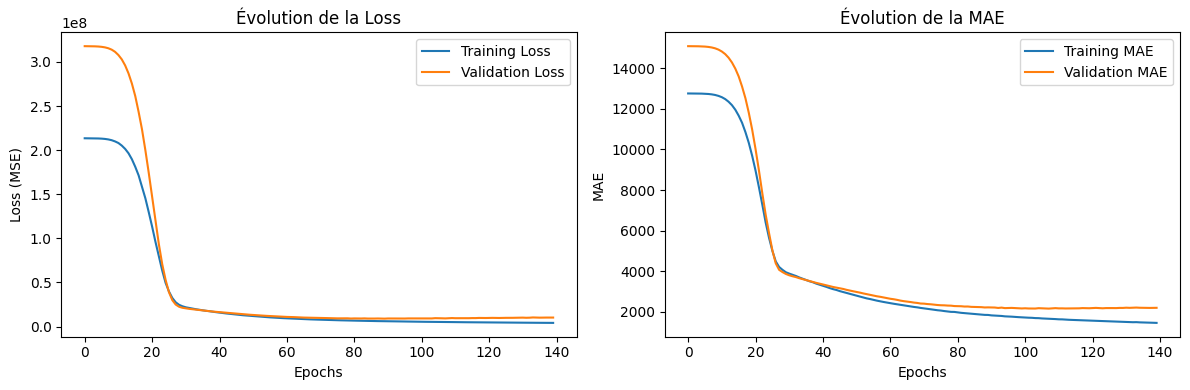

In [3]:
# Visualisation de l'évolution de la loss pendant l'entraînement
plt.figure(figsize=(12, 4))

# Plot de la loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de la Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

# Plot de la MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Évolution de la MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

Sur les deux graphiques précedents, on peut voir que la loss et la MAE diminuent au cours des epochs.
Cela signifie que le modèle est de plus en plus performant.

Bien entendu, nous sommes dans un exemple simpliste a ne pas reproduire, ici le jeux de données carprice ne possède pas assez de données pour un modèle de deep learning.

**Dans ce type de configuration préviligier un modèle de machine learning.**

Performance sur les données de test:
Loss (MSE): 7838250.00
MAE: 1924.10
2/2 [==============================] - 0s 5ms/step


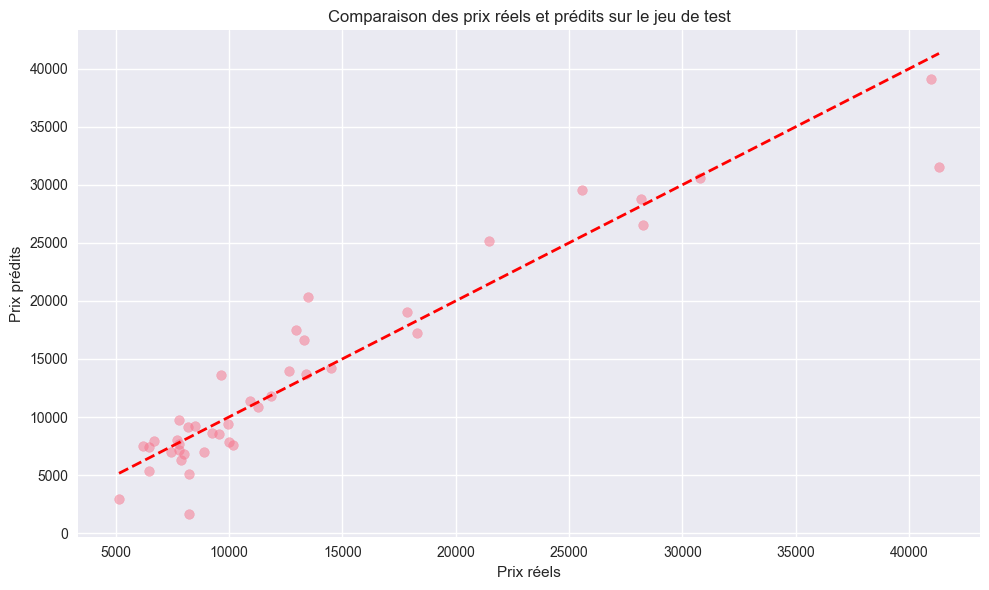

In [42]:
# Évaluation du modèle sur les données de test
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Performance sur les données de test:")
print(f"Loss (MSE): {test_loss:.2f}")
print(f"MAE: {test_mae:.2f}")

# Prédictions sur les données de test
y_pred = model.predict(X_test_scaled)

# Comparaison des prédictions avec les valeurs réelles
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Prix réels')
plt.ylabel('Prix prédits')
plt.title('Comparaison des prix réels et prédits sur le jeu de test')
plt.tight_layout()
plt.show()


In [5]:
# Calcul du coefficient de détermination R2
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"Coefficient de détermination (R²): {r2:.4f}")


Coefficient de détermination (R²): 0.9072


___



In [117]:
print("La dimension des features d'entrée est :", df_shape)

La dimension des features d'entrée est : 23



Si vous avez 23 variables dans votre `input_shape`, cela signifie que chaque neurone (ou cellule) de votre réseau de neurones prendra en entrée un vecteur de 23 valeurs, chaque valeur représentant une des variables de votre entrée.

Pour un neurone avec 23 entrées et une fonction d'activation, comme ReLU, voici comment se présente le calcul réalisé par ce neurone :

 1. **Entrées** : Le neurone reçoit un vecteur d'entrée $\mathbf{x}$ de 23 valeurs.
    - $
    \mathbf{x} = \begin{pmatrix} x_1, x_2, x_3, \dots, x_{23} \end{pmatrix}
    $
 
 2. **Poids** : Le neurone a 23 poids, chacun correspondant à une des 23 variables d'entrée.
    - $
    \mathbf{w} = \begin{pmatrix} w_1, w_2, w_3, \dots, w_{23} \end{pmatrix}
    $
 
 3. **Biais** : Le neurone possède un biais $b$, une constante ajoutée après le produit scalaire.
 
 4. **Calcul linéaire** : Le neurone effectue le produit scalaire entre le vecteur des poids $\mathbf{w}$ et le vecteur d'entrée $\mathbf{x}$, puis ajoute le biais :
    - $
    z = \mathbf{w} \cdot \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \dots + w_{23} x_{23} + b
    $
 
 5. **Fonction d'activation** : Le résultat $z$ est ensuite passé dans une fonction d'activation, comme ReLU, pour produire la sortie $y$ du neurone :
    - $
    y = \text{ReLU}(z) = \text{ReLU}(\mathbf{w} \cdot \mathbf{x} + b)
    $
    Avec ReLU, $y$ sera égal à $z$ si $z > 0$, et 0 sinon.


La fonction relu ressemble à cela : 

<div style="text-align: center;">
<img src="./images/relu.png" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 20px;"/>
<figcaption>Fonction relu</figcaption>
</div>


Elle indique que pour toute valeur négative de x, la valeur de sortie sera 0 et pour toute valeur positive, la valeur de sortie sera la valeur d'entrée car **linéaire**.



___

## Un perceptron pour de la classification 🤔

Dans cette partie nous allons faire la même chose mais cette fois pour de la classification. 

Nous allons utiliser le dataset Titanic que nous avions déja vu dans les précedentes masterclasses. 

In [43]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Chargement des données
df = pd.read_csv('dataset/Titanic-Dataset.csv')

# Préparation des données
# Sélection des features pertinentes
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].copy()

# Conversion des variables catégorielles
X['Sex'] = (X['Sex'] == 'male').astype(int)

# Gestion des valeurs manquantes
X['Age'].fillna(X['Age'].mean(), inplace=True)

# Variable cible
y = df['Survived']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Création du modèle
model = tf.keras.Sequential([
    tf.keras.layers.Dense(12, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Optimisation plus fine
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

# Compilation avec des métriques supplémentaires
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping plus patient
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True,
)

# Entraînement avec plus d'epochs et batch size optimisé
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=24,
    verbose=1,
    callbacks=[early_stopping],

)

Epoch 1/1000
24/24 [==============================] - 5s 36ms/step - loss: 0.6980 - accuracy: 0.5325 - val_loss: 0.6835 - val_accuracy: 0.6713
Epoch 2/1000
24/24 [==============================] - 0s 11ms/step - loss: 0.6787 - accuracy: 0.6467 - val_loss: 0.6701 - val_accuracy: 0.6643
Epoch 3/1000
24/24 [==============================] - 0s 13ms/step - loss: 0.6583 - accuracy: 0.6608 - val_loss: 0.6370 - val_accuracy: 0.6783
Epoch 4/1000
24/24 [==============================] - 0s 7ms/step - loss: 0.6337 - accuracy: 0.6608 - val_loss: 0.5997 - val_accuracy: 0.7063
Epoch 5/1000
24/24 [==============================] - 0s 8ms/step - loss: 0.6227 - accuracy: 0.6749 - val_loss: 0.5713 - val_accuracy: 0.7692
Epoch 6/1000
24/24 [==============================] - 0s 7ms/step - loss: 0.5925 - accuracy: 0.6854 - val_loss: 0.5408 - val_accuracy: 0.7902
Epoch 7/1000
24/24 [==============================] - 0s 8ms/step - loss: 0.5797 - accuracy: 0.6942 - val_loss: 0.5200 - val_accuracy: 0.7902
Epo

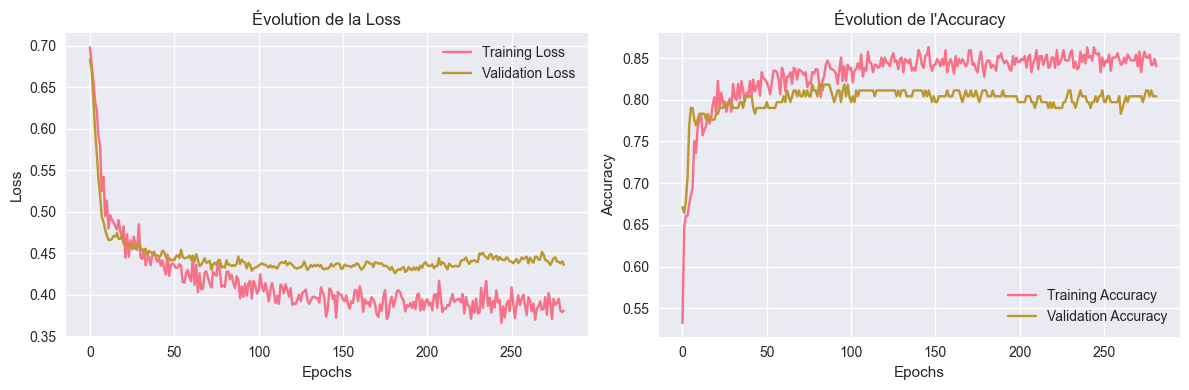

In [44]:
# Visualisation de l'apprentissage
plt.figure(figsize=(12, 4))

# Plot de la loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de la Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot de l'accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de l\'Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

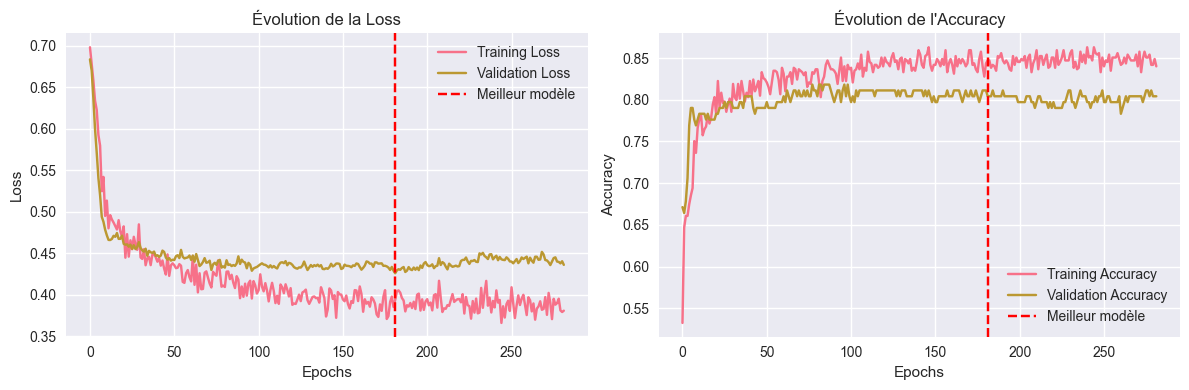

In [45]:
# Visualisation de l'apprentissage avec le meilleur poids
plt.figure(figsize=(12, 4))

# Plot de la loss avec le meilleur point
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axvline(x=early_stopping.best_epoch, color='r', linestyle='--', label='Meilleur modèle')
plt.title('Évolution de la Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot de l'accuracy avec le meilleur point
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axvline(x=early_stopping.best_epoch, color='r', linestyle='--', label='Meilleur modèle')
plt.title('Évolution de l\'Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


6/6 [==============================] - 0s 566us/step


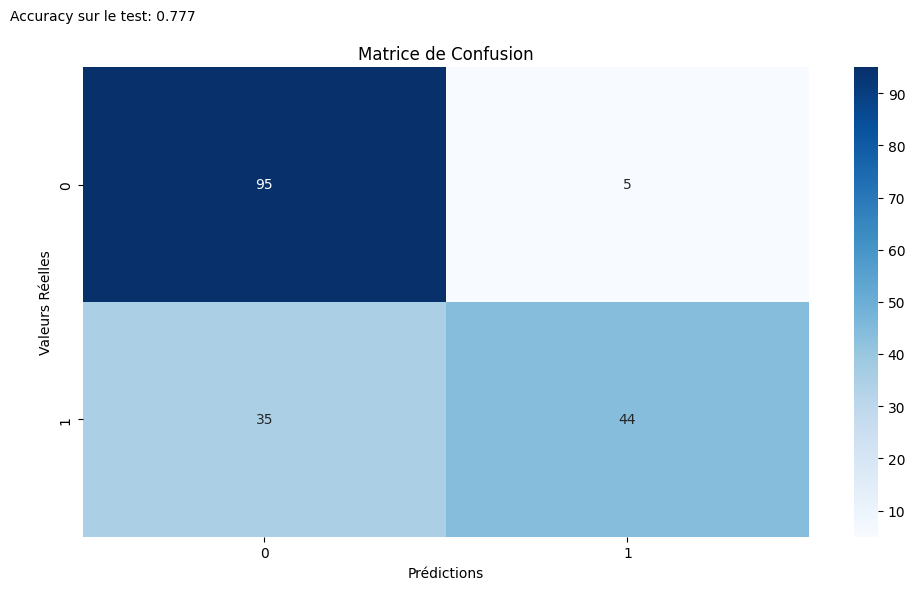

In [9]:
# Évaluation du modèle sur les données de test
y_pred = model.predict(X_test_scaled)
y_pred_classes = (y_pred > 0.5).astype(int)

# Calcul de la matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

# Création de la matrice de confusion
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')

# Ajout des labels pour TP, TN, FP, FN
labels = ['TN', 'FP', 'FN', 'TP']

# Ajout du score de performance
score = model.evaluate(X_test_scaled, y_test, verbose=0)
plt.text(-0.2, -0.2, f'Accuracy sur le test: {score[1]:.3f}')

plt.tight_layout()
plt.show()


In [10]:

# Récupération de l'epoch du meilleur modèle
meilleur_epoch = early_stopping.best_epoch + 1  # +1 car les epochs commencent à 0
print(f"Le modèle s'est arrêté à l'epoch {meilleur_epoch} grâce à l'early stopping")


Le modèle s'est arrêté à l'epoch 276 grâce à l'early stopping


___




## Ok on peut souffler  💨

Nous allons décortiquer tous les éléments que nous avons vu précedement.

Commençons par le code 

```python
model = tf.keras.Sequential([
    tf.keras.layers.Dense(12, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Optimisation plus fine
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

# Compilation avec des métriques supplémentaires
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping plus patient
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True,
)

# Entraînement avec plus d'epochs et batch size optimisé
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=12,
    verbose=1,
    callbacks=[early_stopping],

)
```


### Construction du réseau de neurones 🧠

Dans notre premier bloc de code:

```python 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
```

tf.keras.Sequential permet de créer un réseau de neurones constitué de couches empilées séquentiellement.

Dans ce modèle :

-	La première couche cachée contient 12 neurones, avec une fonction d’activation ReLU, et spécifie ```input_shape```

-	Le deuxième layers contient un dropout il sert à éviter le surapprentissage du modèle (```l'overfitting```)

-	La dernière couche, qui est la couche de sortie, contient 2 neurones avec une fonction d’activation ```Sigmoid```.



Le paramètre ```input_shape``` est défini uniquement pour la première couche afin que le modèle connaisse la forme des données d’entrée.

Enfin, la couche de sortie avec 2 neurones et une activation Sigmoid est adaptée à une tâche de classification binaire : 

- chaque neurone de sortie produit une probabilité pour l’une des classes.

 Jusqu'ici on a :

✅ Éxpliqué le fonctionnement d'un neurone

✅ Créé un réseau de neurones avec des couches cachées

✅ Éxpliqué la fonction d'activation ReLU

✅ Éxpliqué l'importance de l'input_shape

✅ Éxpliqué l'importance de la couche de sortie qui dépend de la tâche que l'on souhaite réaliser (régression ou classification)

✅ Comprendre les dropout

 <div style="background-color: #cce6ff; padding: 15px; border-radius: 5px; border-left: 8px solid #0066ff; margin: 10px 0; width: 90%;">
     <h3 style="color: #0066cc; margin-top: 0;">🔎 Information 🔎</h3>
     <hr style="height:1px;border-width:0;color:gray;background-color:gray">
     <p>
         Le dropout agit comme une règle où, de façon aléatoire à chaque étape d'entraînement, certains  neurones sont "désactivées" temporairement, comme si ils n'étaient pas là. Cela force les autres neurones à prendre plus de responsabilités et à s'impliquer davantage, plutôt que de s'appuyer uniquement sur certains neurones clés. Au lieu de laisser toujours les mêmes neurones "travailler", le réseau devient plus diversifié dans ses connexions et apprend à répartir les informations de manière plus équilibrée.
     </p>
 </div>
  



### L'optimizer et la loss function 🧠

``` python
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])
```

Deux élèments cruciaux dans la construction d'un réseau de neurones :

- L'optimizer : C'est l'algorithme qui ajuste les poids des neurones pour minimiser la loss function.

- La loss function : C'est la fonction qui mesure la différence entre les prédictions du modèle et les valeurs réelles.

Dans le cas d'une régression, la loss function est souvent la ```mean squared error``` ou la ```mean absolute error``` ou encore la ```root mean squared error```.

Dans le cas d'une classification, la loss function est souvent la ```binary crossentropy``` ou la ```categorical crossentropy```.

Maintenant parlons de l'optimizer.
L'optimizer est un algorithme qui ajuste les poids des neurones pour minimiser la loss function.
Il agit dans un espace multidimensionnel (tous les poids du réseau) et cherche à trouver le minimum local de la loss function.

<div style="text-align: center;">
<img src="./images/adam.gif" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>



Le learning rate est un paramètre qui détermine la vitesse à laquelle l'optimizer ajuste les poids.

👉 Plus le learning rate est grand, plus l'optimizer ajuste les poids rapidement, mais il peut manquer le minimum local.

👉Plus le learning rate est petit, plus l'optimizer ajuste les poids lentement, mais il peut converger vers le minimum global.

Il faut donc trouver un équilibre entre la vitesse et la précision du modèle.

## Early stopping 🛑 et entrainement 💪🏼

```python 
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True,
)

# Entraînement avec plus d'epochs et batch size optimisé
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=12,
    verbose=1,
    callbacks=[early_stopping],
)
```

Parlons dans un premier temps de la construction du modèle, j'entends par la le fit sur l'ensemble de nos données d'entrainement.

Il prend en paramètre dans cet éxemple: 

- ```X_train_scaled``` : nos données d'entrainement standardisées
- ```y_train``` : nos étiquettes de classe ou dans le cas de la regression nos valeurs cibles
- ```validation_split=0.2``` : 20% des données d'entrainement sont utilisées pour la validation
- ```epochs=1000``` : 1000 époques d'entrainement
- ```batch_size=12``` : 12 données par batch
- ```verbose=1``` : affichage des informations sur l'entrainement
- ```callbacks=[early_stopping]``` : utilisation de l'early stopping pour éviter le surapprentissage


Garder en tête les élèments suivants :

- L'epoch correspond à une itération sur l'ensemble de nos données d'entrainement, en une époque toutes les données d'entrainement sont passées dans le modèle.
-	Le batch size correspond au nombre de données que le modèle va utiliser pour une itération dans une époque.
	-	Si batch size = 12, le modèle va diviser les données d’entraînement en batches de 12 exemples chacun.
	-	Pour chaque batch, le modèle va faire une prédiction, comparer cette prédiction à la valeur réelle pour calculer l’erreur (loss), puis appliquer la rétropropagation pour calculer les gradients.
	-	Enfin, le modèle met à jour les poids des neurones en fonction des gradients calculés pour réduire l’erreur commise.

Une petite image afin de conceptualiser l'epoch, le batch size, le nombre d'itération ainsi que le recalcul des poids:
<div style="text-align: center;">
<img src="./images/epochvsbatch.png" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>


Le but est le suivant, minimiser la loss function.
Cette recherche de minima local est réalisée grâce à l'optimizer.
Et entre chaque batch le modèle met à jour les poids des neurones en fonction des gradients calculés pour réduire l’erreur commise.

Et maintenant parlons de l'early stopping.

C'est assez simple à comprendre, le modèle va s'entrainer et va évaluer sa performance sur les données de validation à chaque époque.
Si la performance ne s'améliore pas, le modèle va s'arrêter.

```python 
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True,
)
```
Ici je précise que je veux que le modèle arrete son entrainement si au bout de 100 epoch je n'ai pas amélioré ma loss function (val_loss).

Cela permet d'éviter le surapprentissage du modèle.

Je dois ensuite restaurer les best weights du modèle avec l'aide de l'enregistrement des valeurs dans mon callback. 

Cela se faire de la sorte :
```python 
restore_best_weights=True,
```

## Les indicateurs à surveiller 💪🏼


### Learning curve 📈 pour la regression et la classification 
La learning curve permet de visualiser l'évolution de la loss function et de l'accuracy au cours de l'entrainement dans le cas d'une classification. 

<div style="text-align: center;">
<img src="./images/learingcurve.png" width="900" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>


Elle permet d'identifier plusieurs points intéressants :

-	Le surapprentissage
-	Le sous apprentissage
-	Le point optimal d'arrêt de l'entrainement

<div style="text-align: center;">
<img src="./images/overunder.png" width="500" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

Nous pouvons le voir maintenant sur notre précedente courbe:

<div style="text-align: center;">
<img src="./images/earlystop.png" width="900" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>



Dans l'image précèdente, le meilleur modèle est celui qui a été arrêté grâce à l'early stopping.
Ici j'overfit un peu, malgrès le fait que ma loss de validation continue de baisser.

### Les indicateurs de performance 📈

#### Lecture du fit verbose 1
Nous l'avons utilisé précedement, il s'agit de l'ensemble des valeurs de loss entre autres au cours de l'entrainement.

Elle se retrouve dans le history de notre fit.

<div style="text-align: center;">
<img src="./images/loss.png" width="900" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

Dans la plupart des cas ou pour l'analyse des images que nous allons faire garder en tête une chose: 

- Le but est de minimiser la loss function
- Plus la loss est faible, plus le modèle est performant
- Plus la loss est élevée, plus le modèle est mauvais

Attention, il faut que cette loss soit la plus faible possible certe mais aussi la val_loss qui représente la loss sur les données de validation.
#### La matrice de confusion 🟰

Permettant de juger de la performance de notre modèle.

La matrice de confusion est une matrice, avec en ligne les valeurs réelles et en colonne les prédictions du modèle.

Dans le cas d'une classification binaire:
<div style="text-align: center;">
<img src="./images/confusion.png" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>



#### Le $R^2$ 🏃🏽‍♂️
  
Le  $R^2$  est un indicateur de performance pour une régression.

Il mesure la proportion de la variance des données expliquée par le modèle par rapport à la droite de régression. Plus cette valeur est proche de 1, plus le modèle est performant dans la prédiction des valeurs observées.

En python il se calcule de la sorte:

```python
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

```

  <div style="text-align: center;">
<img src="./images/regline.png" width="500" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

## Parlons maintenant d'image et de CNN 💪🏼

### Une image 🌆
Avant de parler de Cnn il est important de comprendre ce qu'est une image et comment un ordinateur la perçoit.

<div style="text-align: center;">
<img src="./images/pixel.jpg" width="300" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

Une image est composée de pixels, un pixel est un point de l'image.

Et chaque pixel est composé de trois valeurs, le rouge, le vert et le bleu.
C'est le mélange entre ces trois valeurs qui permet de définir la couleur d'un pixel.

<div style="text-align: center;">
<img src="./images/pixel.png" width="450" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

Cela implique que nous pouvons donc isoler chacun des trois grandes couleurs.

Prenons l'image suivante :

<div style="text-align: center;">
<img src="./images/meme.jpg" width="300" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>


Elle est composé de 3 canaux, le rouge, le vert et le bleu.

Voici l'image avec les 3 canaux séparés :

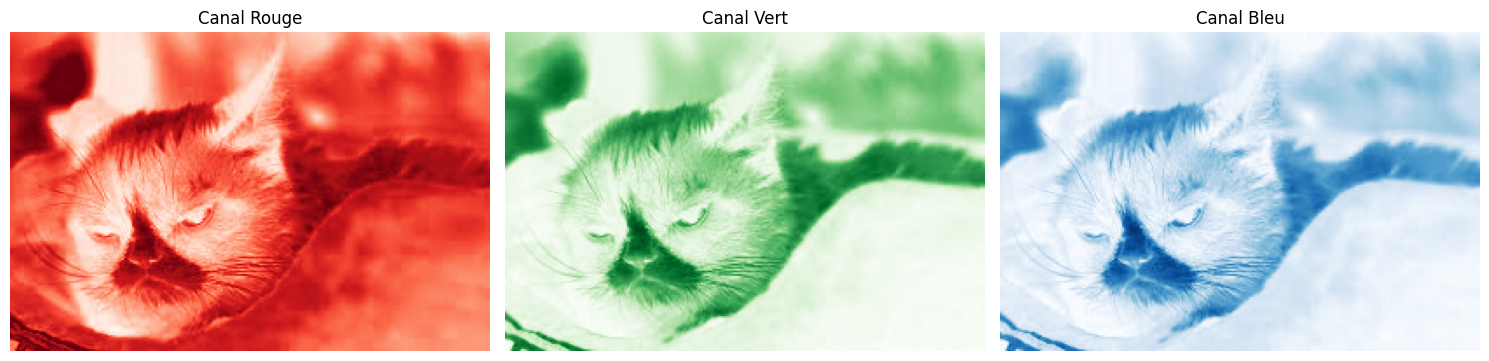

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Charger l'image
image = mpimg.imread('./images/meme.jpg')

# Créer une figure avec 3 sous-graphiques
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Afficher les composantes R, G, B séparément
ax1.imshow(image[0:,:,0], cmap='Reds')
ax1.set_title('Canal Rouge')
ax1.axis('off')

ax2.imshow(image[:,:,1], cmap='Greens')
ax2.set_title('Canal Vert')
ax2.axis('off')

ax3.imshow(image[:,:,2], cmap='Blues')
ax3.set_title('Canal Bleu')
ax3.axis('off')

plt.tight_layout()
plt.show()


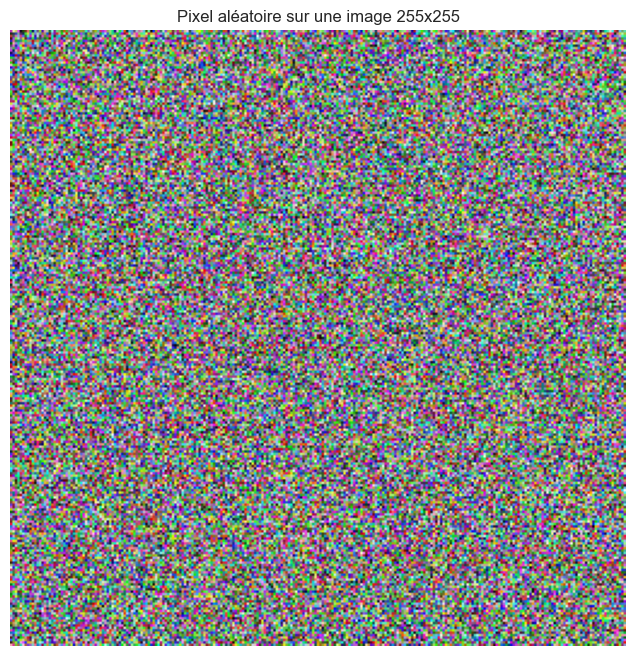

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Création d'une image aléatoire 255x255 avec 3 canaux (RGB)
image_aleatoire = np.random.randint(0, 255, size=(255, 255, 3), dtype=np.uint8)

# Affichage de l'image
plt.figure(figsize=(8, 8))
plt.imshow(image_aleatoire)
plt.title('Pixel aléatoire sur une image 255x255')
plt.axis('off')
plt.show()


```Retenez bien ceci : une image est composée de pixels, et chaque pixel est représenté par trois valeurs, correspondant aux niveaux de rouge, de vert et de bleu.```

La valeur de chaque pixel est donc un triplet de valeurs compris entre 0 et 255.

Par exemple, pour le vert, le triplet sera (0, 255, 0), pour le rouge, (255, 0, 0), et pour le bleu, (0, 0, 255).

Le but principal d’un CNN est de traiter les valeurs de chaque pixel.

Pour cela, le CNN utilise des filtres de convolution qui mettent en évidence des caractéristiques spécifiques dans les données.

Ces filtres de convolution sont appliqués à chaque pixel de l’image pour en extraire des informations supplémentaires.

Toutes ces informations sont ensuite transmises à un réseau de neurones dense qui réalise la tâche de prédiction souhaitée.




### Le cnn 🤖

Afin d'effectuer une classification d'image nous allons utiliser une Convolutional Neural Network (CNN).

Un cnn ressemble à cela: 

<div style="text-align: center;">
<img src="./images/cnn.jpg" width="900" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>



Ok, on a beaucoup de nouveaux éléments à aborder.

Kernel, convolution, pooling, flatten ... Pas tant que cela finalement 😅

La définition de chacun de ces éléments est primordiale pour comprendre le fonctionnement d'une CNN.

- Kernel : Filtre de convolution
- Convolution : Opération mathématique qui permet de mettre en évidence des caractéristiques dans les données
- Pooling : Réduction de la dimensionnalité des données
- Flatten : Transformation des données en vecteur

Rien de bien compliqué finalement, dites vous une chose, les couches de convolution sont des couches cachées. 
Mais elles sont spéciales, elles permettront de mettre en évidence des caractéristiques dans les données. 

Vous vous rappelez des **pixels** ? Un CNN va les traiter. Et en tirer de l'information.


### La convolution 🤏

La convolution est une opération qui permet de mettre en évidence des caractéristiques dans les données images.

Elle se fait grâce à un filtre de convolution.
Les filtres aussi appelés kernels sont des matrices de poids qui permettront de mettre en évidence des caractéristiques dans les données.

Dans un reseaux CNN il sont mis en place dans les couches de convolution. Et sont initiés de manière aléatoire.

Cependant il existe des kernels connus qui permettront de mettre en évidence des caractéristiques particulières.

Par exemple le kernel de Sobel permet de mettre en évidence les contours dans les données.

<div style="text-align: center;">
<img src="./images/sobel.jpg" width="500" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>




Le gif ci-dessous représente la façon dont le kernel va passer sur l'image afin d'en créer une deuxième : 
<div style="text-align: center;">
<img src="./images/conv.gif" width="500" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>


Essayons de faire un éxemple avec l'image suivante : 

<div style="text-align: center;">
<img src="./images/meme.jpg" width="500" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>


En appliquant une étape de convolution à cette image nous obtiendrons les images suivantes avec des kernel aléatoires :

<div style="text-align: center;">
<img src="./images/exconv.png" width="900" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>


### Le pooling 🤏

Le pooling est une opération qui permet de réduire la dimension des données.

Elle se fait grâce à une fonction de pooling.

La fonction de pooling la plus courante est la fonction max pooling.

Elle permet de réduire la dimension des données en prenant la valeur maximale dans chaque fenêtre.

Comme sur l'image suivante :

<div style="text-align: center;">
<img src="./images/pool.gif" width="400" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

Il éxiste des fonction de pooling communes comme le max pooling ou le average pooling.

Chacun a ses avantages et ses inconvénients.

- Le max pooling est souvent utilisé car il permet de conserver les informations les plus importantes dans les données.

- Le average pooling est souvent utilisé car il permet de réduire la dimension des données.


### Le flatten 🤏

Le **flatten** est une opération qui transforme les données de sortie d’un réseau de convolution (souvent une matrice multidimensionnelle) en un vecteur unidimensionnel.

Cela permet à notre réseau de neurones dense de traiter les données sous une forme qu’il peut comprendre.

Le principe est simple : le flatten prend la dernière matrice de données (issue des convolutions et du pooling) et la “déroule” en une seule ligne de valeurs.

<div style="text-align: center;">
<img src="./images/flatten.png" width="600" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

Le but est de transformer cette matrice en un vecteur, qui sera ensuite envoyé au réseau de neurones dense pour effectuer la classification ou toute autre tâche de sortie.

Finalement, la sortie du flatten est similaire aux colonnes d’un jeu de données classique, sauf qu’elle représente ici toutes les caractéristiques extraites par les couches de convolution et de pooling appliquées au départ sur l’image.


## Le Cnn par la pratique 💪🏼


Nous allons faire de la classification de pokemon. 

Le but sera de determiner en fonction d'une image de pokemon à quelle classe il appartient.

Nous allons commencer par analyser notre dataset.


In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = 'dataset/pokemon/'
classes = os.listdir(dataset_path)
print(f'Total number of categories: {len(classes)}')
print(classes)


Total number of categories: 150
['Zapdos', 'Kadabra', 'Omanyte', 'Shellder', 'Bellsprout', 'Eevee', 'Jolteon', 'Hypno', 'Seel', 'Zubat', 'Graveler', 'Magneton', 'Abra', 'Kingler', 'Alakazam', 'Clefable', 'Gyarados', 'Poliwag', 'Rapidash', 'Machamp', 'Pinsir', 'Muk', 'Seaking', 'Magikarp', 'Goldeen', 'Venusaur', 'Flareon', 'Jigglypuff', 'Doduo', 'Weedle', 'Vileplume', 'Arcanine', 'Tentacruel', 'Gloom', 'Charmeleon', 'Articuno', 'Sandshrew', 'Spearow', 'Marowak', 'Clefairy', 'dataset', 'Snorlax', 'Scyther', 'Primeape', 'Diglett', 'Onix', 'Mankey', 'Rattata', 'Voltorb', 'Gengar', 'Gastly', 'Cloyster', 'Weepinbell', 'Dragonair', 'Squirtle', 'Pikachu', 'Victreebel', 'Charmander', 'Staryu', 'Venonat', 'Vaporeon', 'Ivysaur', 'Krabby', 'Drowzee', 'Sandslash', 'Kangaskhan', 'Chansey', 'Butterfree', 'Starmie', 'Magmar', 'Beedrill', 'Ninetales', 'Magnemite', 'Metapod', 'Electrode', 'Raichu', 'Fearow', 'Mewtwo', 'Kabuto', 'Pidgeotto', 'Hitmonchan', 'Blastoise', 'Weezing', 'Golbat', 'Seadra', 'Rhyh

Créons un dictionnaire avec l'ensemble des classes et le nombre d'images associées.

```python
class_counts = {class_name: len(os.listdir(os.path.join(dataset_path, class_name))) for class_name in classes}
print(class_counts)
```
Le join me permet de créer un chemin vers le dossier de chaque classe.

Ensuite je le compte et j'y associe le nombre d'images.

Je mets cela dans un dictionnaire.


In [4]:
class_counts = {class_name: len(os.listdir(os.path.join(dataset_path, class_name))) for class_name in classes}
print(class_counts)

{'Zapdos': 60, 'Kadabra': 61, 'Omanyte': 55, 'Shellder': 81, 'Bellsprout': 55, 'Eevee': 41, 'Jolteon': 64, 'Hypno': 63, 'Seel': 61, 'Zubat': 49, 'Graveler': 58, 'Magneton': 59, 'Abra': 42, 'Kingler': 69, 'Alakazam': 49, 'Clefable': 49, 'Gyarados': 68, 'Poliwag': 65, 'Rapidash': 83, 'Machamp': 72, 'Pinsir': 63, 'Muk': 71, 'Seaking': 65, 'Magikarp': 59, 'Goldeen': 58, 'Venusaur': 66, 'Flareon': 59, 'Jigglypuff': 65, 'Doduo': 48, 'Weedle': 59, 'Vileplume': 67, 'Arcanine': 61, 'Tentacruel': 57, 'Gloom': 58, 'Charmeleon': 65, 'Articuno': 56, 'Sandshrew': 66, 'Spearow': 130, 'Marowak': 70, 'Clefairy': 60, 'dataset': 150, 'Snorlax': 69, 'Scyther': 68, 'Primeape': 70, 'Diglett': 51, 'Onix': 64, 'Mankey': 72, 'Rattata': 67, 'Voltorb': 65, 'Gengar': 60, 'Gastly': 50, 'Cloyster': 60, 'Weepinbell': 51, 'Dragonair': 65, 'Squirtle': 280, 'Pikachu': 298, 'Victreebel': 55, 'Charmander': 296, 'Staryu': 60, 'Venonat': 57, 'Vaporeon': 68, 'Ivysaur': 53, 'Krabby': 64, 'Drowzee': 60, 'Sandslash': 71, 'Kang

Analysons la fréquence des classes dans notre dataset.


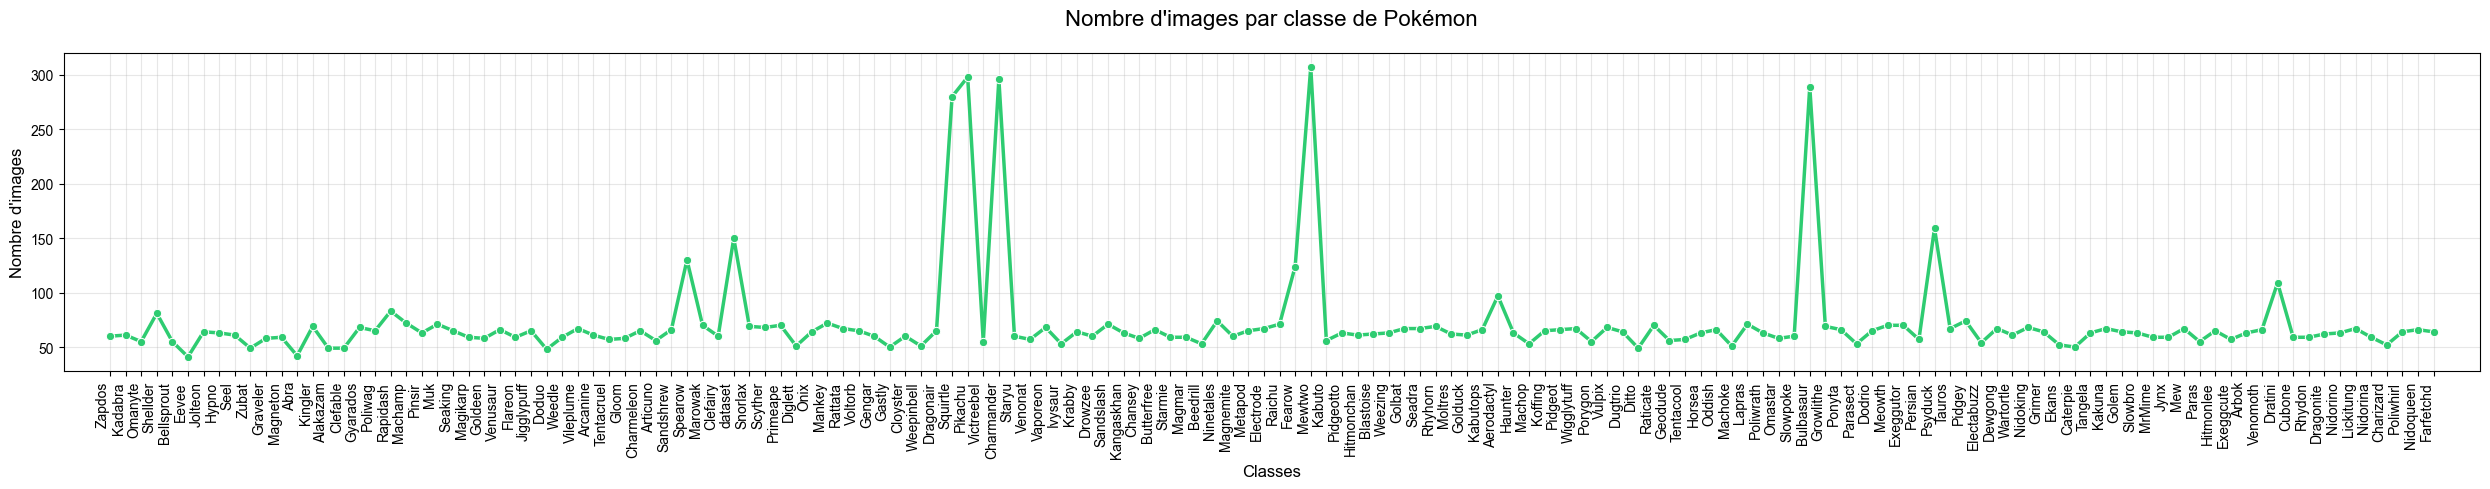

In [3]:
plt.figure(figsize=(25, 5))
plt.grid(True, alpha=0.3)
sns.lineplot(x=list(class_counts.keys()),
            y=list(class_counts.values()),
            color='#2ecc71',
            linewidth=2.5,
            marker='o')

plt.title('Nombre d\'images par classe de Pokémon',
         fontsize=16,
         pad=20)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Nombre d\'images', fontsize=12)

plt.xticks(rotation=90, ha='right')
plt.margins(x=0.02)

# Améliorer le style
plt.style.use('seaborn')
sns.set_palette("husl")

plt.tight_layout()
plt.show()

On peut déja remarquer que notre dataset est déséquilibré.

Nous avons des classes avec un nombre d'images différentes.
Affichons dans l'ordre décroissant les classes avec le plus d'images.

```python
sorted_class_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
print(sorted_class_counts)
```

Explication détaillée du tri des classes :

1. class_counts.items() :
   - Retourne les paires clé-valeur du dictionnaire sous forme de tuples
   - Exemple avec class_counts = {"pikachu": 5, "bulbasaur": 2}
   - Résultat : [("pikachu", 5), ("bulbasaur", 2)]

2. lambda x: x[1] :
   - Fonction anonyme qui prend un paramètre x (chaque tuple)
   - Retourne x[1] (le deuxième élément du tuple = nombre d'images)
   - Utilisée comme clé de tri

3. sorted(..., key=lambda..., reverse=True) :
   - Trie la liste selon la clé spécifiée (nombre d'images)
   - reverse=True : tri décroissant
   - Sans reverse=True : tri croissant par défaut

In [5]:
print(class_counts.items())
sorted_class_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:4]
print(sorted_class_counts)

dict_items([('Zapdos', 60), ('Kadabra', 61), ('Omanyte', 55), ('Shellder', 81), ('Bellsprout', 55), ('Eevee', 41), ('Jolteon', 64), ('Hypno', 63), ('Seel', 61), ('Zubat', 49), ('Graveler', 58), ('Magneton', 59), ('Abra', 42), ('Kingler', 69), ('Alakazam', 49), ('Clefable', 49), ('Gyarados', 68), ('Poliwag', 65), ('Rapidash', 83), ('Machamp', 72), ('Pinsir', 63), ('Muk', 71), ('Seaking', 65), ('Magikarp', 59), ('Goldeen', 58), ('Venusaur', 66), ('Flareon', 59), ('Jigglypuff', 65), ('Doduo', 48), ('Weedle', 59), ('Vileplume', 67), ('Arcanine', 61), ('Tentacruel', 57), ('Gloom', 58), ('Charmeleon', 65), ('Articuno', 56), ('Sandshrew', 66), ('Spearow', 130), ('Marowak', 70), ('Clefairy', 60), ('dataset', 150), ('Snorlax', 69), ('Scyther', 68), ('Primeape', 70), ('Diglett', 51), ('Onix', 64), ('Mankey', 72), ('Rattata', 67), ('Voltorb', 65), ('Gengar', 60), ('Gastly', 50), ('Cloyster', 60), ('Weepinbell', 51), ('Dragonair', 65), ('Squirtle', 280), ('Pikachu', 298), ('Victreebel', 55), ('Cha

Sachant que le nombre d'image est déséquilibré, nous allons faire de la classification sur un sous ensemble de notre dataset. Pour les classes avec le plus d'images  c'est à dire: 
 - Mewtwo: 307 images
 - Pikachu: 298 images 
 - Charmander: 296 images
 - Bulbasaur: 289 images


Dans un premier temps construisons notre X et Y

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Error processing ed9eb0e7d3494c6992e06196f5b7cc05.svg


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: cHRM chunk does not match sRGB
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: cHRM chunk does not match sRGB
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known

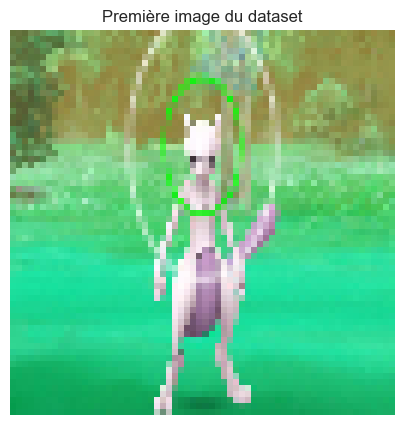

In [6]:
import cv2 as cv
import numpy as np
from keras.utils import to_categorical
classes_four_best = [i[0] for i in sorted_class_counts]
X = [] # List for images
Y = [] # List for labels

for c in sorted_class_counts:
    dir_path = os.path.join(dataset_path, c[0])
    label = classes_four_best.index(c[0])

    for filename in os.listdir(dir_path):
        try:
            # Load and resize image
            image_path = os.path.join(dir_path, filename)
            image = cv.imread(image_path)
            resized = cv.resize(image, (64, 64)) # Resizing images to (96, 96)
            X.append(resized)
            Y.append(label)
        except:
            print(f"Error processing {filename}")
            continue

# Conversion de la première image en format uint8 pour l'affichage
premiere_image = X[0].astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(premiere_image)
plt.title('Première image du dataset')
plt.axis('off')
plt.show()


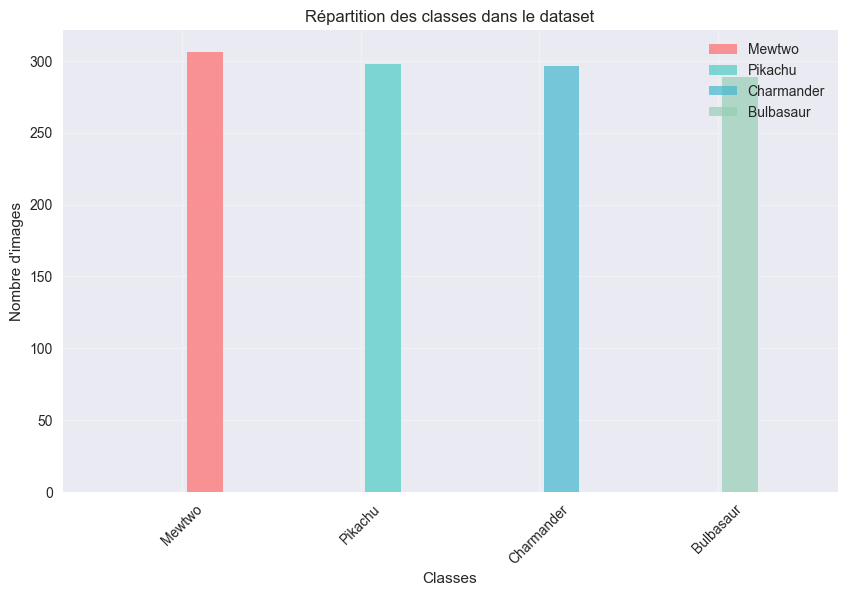

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Définir des couleurs différentes pour chaque classe
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Créer un histogramme pour chaque classe individuellement
for i, classe in enumerate(classes_four_best):
    mask = np.array(Y) == i
    plt.hist(np.array(Y)[mask], bins=len(set(Y)), rwidth=0.8, color=colors[i], alpha=0.7, label=classe)

plt.title('Répartition des classes dans le dataset')
plt.xlabel('Classes')
plt.ylabel('Nombre d\'images')
plt.xticks(range(len(classes_four_best)), classes_four_best, rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

On est pas trop mal, on a redimensionné nos images et on a récupéré les labels associés à chaque image.

On a commencé à construire notre dataset pour notre futur cnn. 


In [8]:
from sklearn.model_selection import train_test_split

# Dans un premier nous allons devoir convertir notre liste d'image resize en tableau numpy.
X = np.array(X).reshape(-1, 64, 64, 3)
#Pour le scaling rien de plus simple
X_scaled = X / 255.0 # Car j'ai des valeurs entre 0 et 255
y = to_categorical(Y, num_classes = len(classes_four_best))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,  shuffle = True, random_state = 6)


Pourquoi -1 ?
- -1 dit à NumPy : "calcule automatiquement cette dimension"
NumPy détermine le nombre d'images en fonction du nombre total d'éléments
Par exemple, si X contient 1000 images, le reshape donnera (1000, 128, 128, 3)

#### Data Augmentation 🌆

Nous allons maintenant faire ce que nous appelons de la datageneration.

Le but ici est de créer plus d'image en prenant nos images actuelles.

Le but est d'augmenter chaque image afin d'en avoir de nouvelles de la sorte : 

<div style="text-align: center;">
<img src="./images/datagen.png" width="900" style="box-shadow: 2px 2px 5px rgba(0, 0, 0, 0.3);border-radius: 0px;"/>
</div>

Pour ce faire nous allons utiliser la librairie Keras.

```python
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=50,
    width_shift_range=0.2,
    horizontal_flip = True,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
)
```

Pour plus d'informations sur ImageDataGenerator, voir la documentation officielle :

### 👉 [Pour toutes les options de cette méthode](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator)


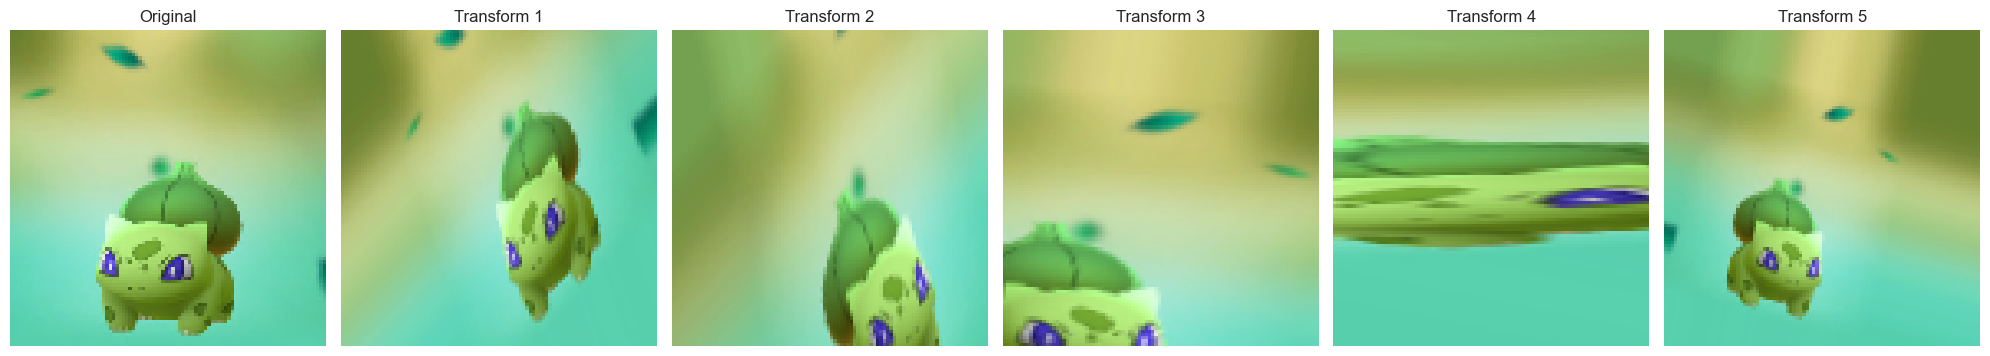

In [40]:
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# Création du générateur d'images
image_generator = ImageDataGenerator(
    rotation_range=50,
    width_shift_range=0.2,
    horizontal_flip=True,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.9
)

def afficher_transformations(image, nb_transformations=5):
    """
    Affiche une image et ses transformations générées par le DataGenerator
    """
    # S'assurer que l'image est normalisée entre 0 et 1
    if image.max() > 1:
        image = image / 255.0

    # Reshape l'image pour le datagen (batch_size, height, width, channels)
    img = np.expand_dims(image, 0)

    # Création de la figure
    fig, axes = plt.subplots(1, nb_transformations + 1, figsize=(20, 4))

    # Affichage de l'image originale
    axes[0].imshow(image)
    axes[0].set_title('Original')
    axes[0].axis('off')

    # Génération et affichage des transformations
    i = 0
    for batch in image_generator.flow(img, batch_size=1):
        axes[i+1].imshow(batch[0])  # Clip pour éviter les valeurs hors limites
        axes[i+1].set_title(f'Transform {i+1}')
        axes[i+1].axis('off')
        i += 1
        if i >= nb_transformations:
            break

    plt.tight_layout()
    plt.show()

# Test avec la première image
afficher_transformations(X_train[869])

<div style="background-color: #ffcccc; padding: 15px; border-radius: 5px; border-left: 8px solid #ff0000; margin: 10px 0; width: 90%;">
    <h3 style="color: #cc0000; margin-top: 0;">⛔️ Attention ⛔️</h3>
    <hr style="height:1px;border-width:0;color:gray;background-color:gray">
    <p>
         <p><code>datagen.fit(X_train)</code> ne génère pas de nouvelles images et ne les stocke pas en mémoire.</p>
         <p>À chaque epoch, les images sont générées dynamiquement.</p>
         <p>Le nombre total d'images vues par le modèle dépend de:</p>
         <ul>
             <li>batch_size</li>
             <li>epochs</li> 
             <li>nombre d'images initiales</li>
             <li>steps_per_epoch (si spécifié)</li>
         </ul>
   
    </p>
</div>

### 🔥 Le modèle 🔥

Nous allons dans un premier temps proposer un modèle simple. 

Nous allons utiliser la fonction Sequential de Keras.



In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_generator = ImageDataGenerator(
    rotation_range=20,  # Réduction de la rotation pour accélérer
    zoom_range=0.15,    # Légère augmentation du zoom
    horizontal_flip=True,
    width_shift_range=0.1,  # Ajout de translation pour plus de robustesse
    height_shift_range=0.1
)

image_generator.fit(X_train)

# Création du modèle optimisé
model_1 = Sequential([
    # Première couche de convolution + Batch Normalization
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3), padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),  # Légère régularisation

    # Deuxième couche de convolution + Batch Normalization
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    # Troisième couche de convolution + Batch Normalization
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),  # Régularisation augmentée

    # Quatrième couche de convolution pour plus de profondeur
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.5),

    # Aplatissement
    Flatten(),

    # Couche dense plus légère
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Couche de sortie pour les 4 classes
    Dense(4, activation='softmax')
])

In [11]:
import tensorflow as tf


# Définition du learning rate et de l'optimiseur avec un taux d'apprentissage plus adapté aux CNNs
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilation avec métriques spécifiques pour la classification d'images
model_1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', 'AUC']
)

# Callbacks optimisés pour CNN
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',  # Surveillance de l'accuracy plutôt que la loss
    patience=20,  # Patience réduite
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_pokemon_cnn.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint]

# Entraînement optimisé pour CNN
history = model_1.fit(
    image_generator.flow(X_train, y_train, batch_size=32),  # Batch size augmenté
    epochs=200,  # Nombre d'epochs réduit mais avec early stopping
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1,

)

Epoch 1/200
26/26 [==============================] - ETA: 0s - loss: 0.5657 - accuracy: 0.8413 - precision: 0.8528 - recall: 0.8353 - auc: 0.9604
Epoch 1: val_accuracy improved from -inf to 0.70308, saving model to best_pokemon_cnn.h5
26/26 [==============================] - 5s 150ms/step - loss: 0.5657 - accuracy: 0.8413 - precision: 0.8528 - recall: 0.8353 - auc: 0.9604 - val_loss: 1.6871 - val_accuracy: 0.7031 - val_precision: 0.7051 - val_recall: 0.7031 - val_auc: 0.8582
Epoch 2/200
26/26 [==============================] - ETA: 0s - loss: 0.4794 - accuracy: 0.8425 - precision: 0.8491 - recall: 0.8317 - auc: 0.9664
Epoch 2: val_accuracy improved from 0.70308 to 0.83193, saving model to best_pokemon_cnn.h5
26/26 [==============================] - 4s 152ms/step - loss: 0.4794 - accuracy: 0.8425 - precision: 0.8491 - recall: 0.8317 - auc: 0.9664 - val_loss: 0.6905 - val_accuracy: 0.8319 - val_precision: 0.8338 - val_recall: 0.8291 - val_auc: 0.9556
Epoch 3/200
26/26 [==================

Analysons un peu la performance de notre modèle. 

Pour ce faire nous connaissons la chanson: 

- Learning curve
- Confusion matrix

Commençons par la learning curve:

34


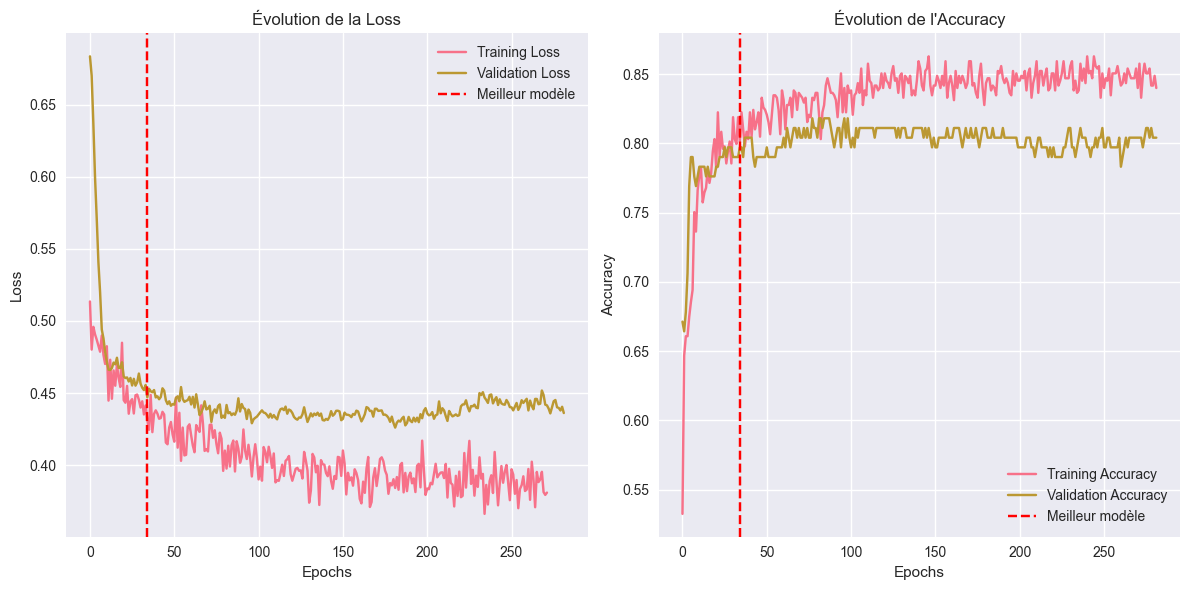

In [56]:
print(early_stopping.best_epoch)
# Visualisation de l'apprentissage avec le meilleur poids
plt.figure(figsize=(12, 6))

# Plot de la loss avec le meilleur point
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'][10:], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axvline(x=early_stopping.best_epoch, color='r', linestyle='--', label='Meilleur modèle')
plt.title('Évolution de la Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot de l'accuracy avec le meilleur point
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axvline(x=early_stopping.best_epoch, color='r', linestyle='--', label='Meilleur modèle')
plt.title('Évolution de l\'Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Et maintenant la confusion matrix:


12/12 [==============================] - 3s 201ms/step


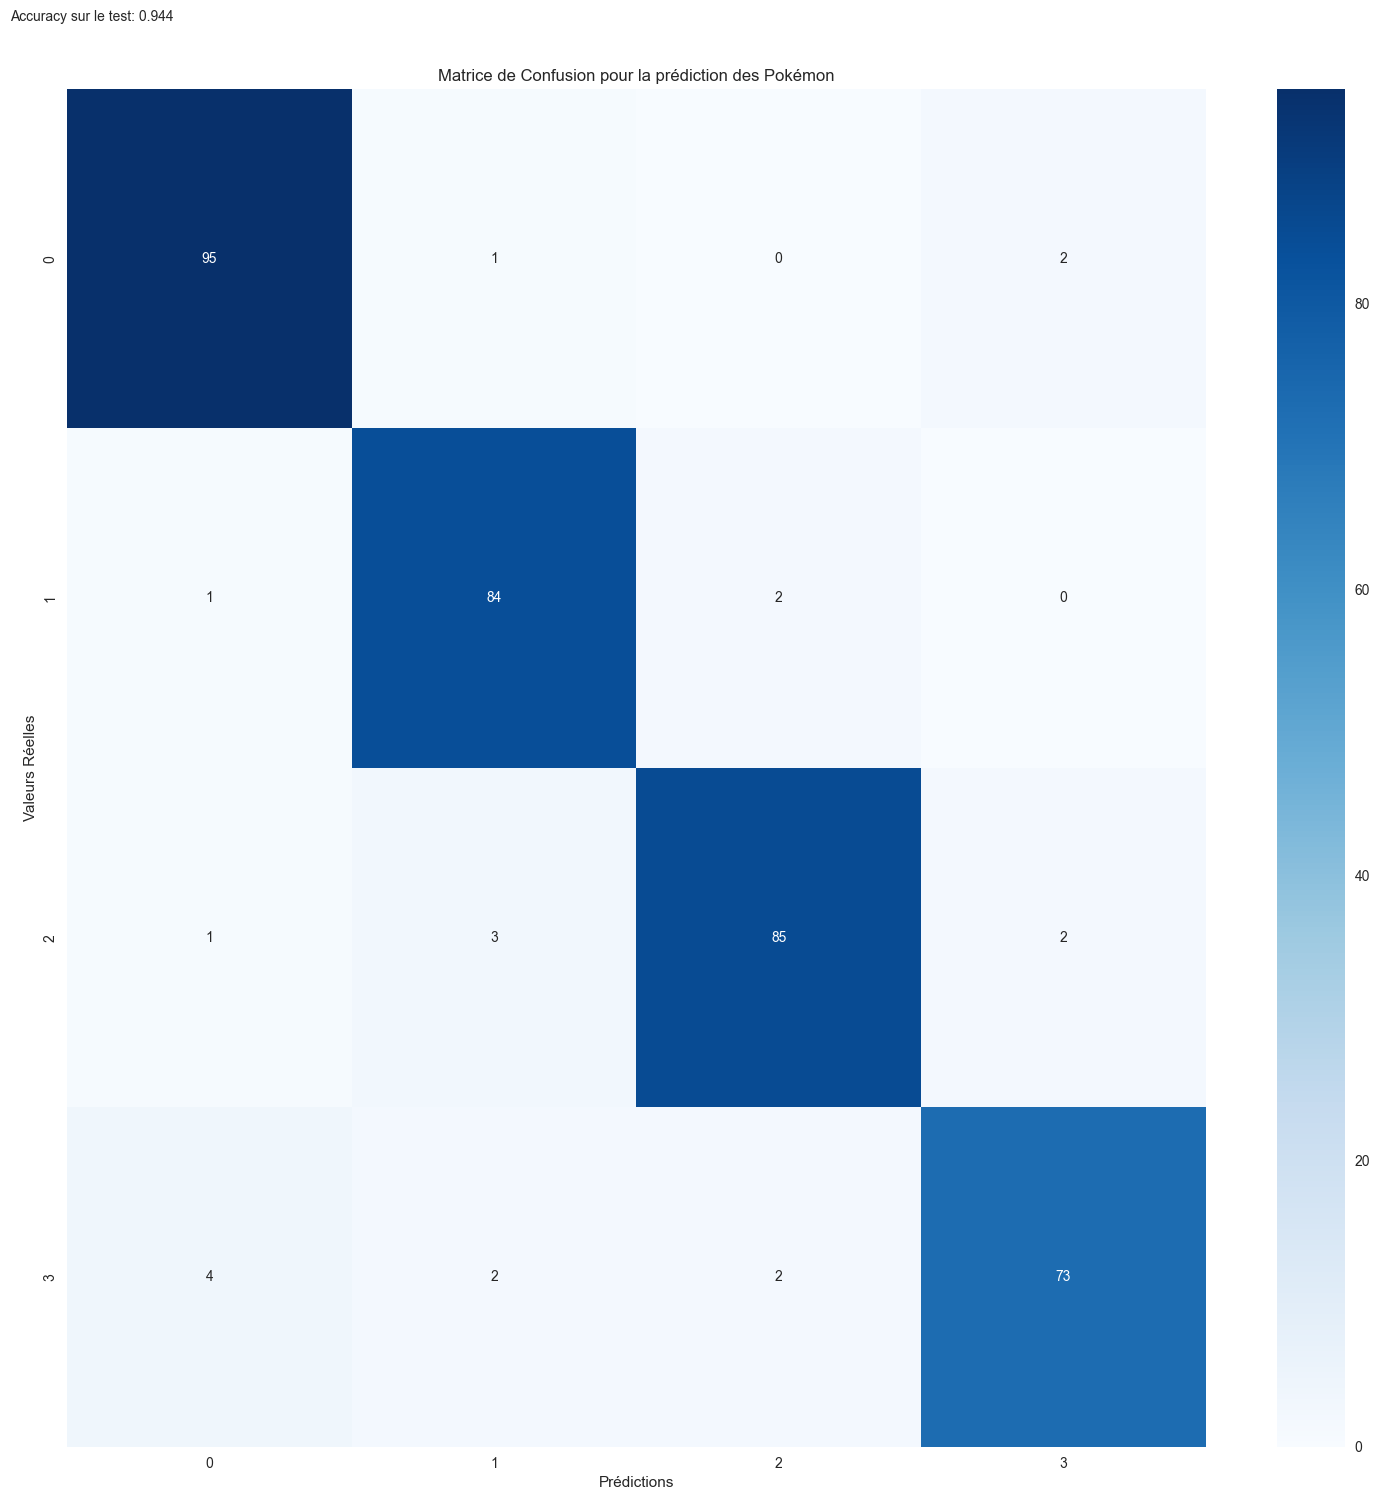

In [57]:
# Évaluation du modèle sur les données de test
y_pred = model_1.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Calcul de la matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtenir les noms des classes de Pokémon
class_names = list(range(len(y_test[0])))  # Nombre de classes

cm = confusion_matrix(y_test_classes, y_pred_classes)

# Création de la matrice de confusion
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matrice de Confusion pour la prédiction des Pokémon')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')

# Ajout du score de performance
score = model_1.evaluate(X_test, y_test, verbose=0)
plt.text(-0.2, -0.2, f'Accuracy sur le test: {score[1]:.3f}')

plt.tight_layout()
plt.show()

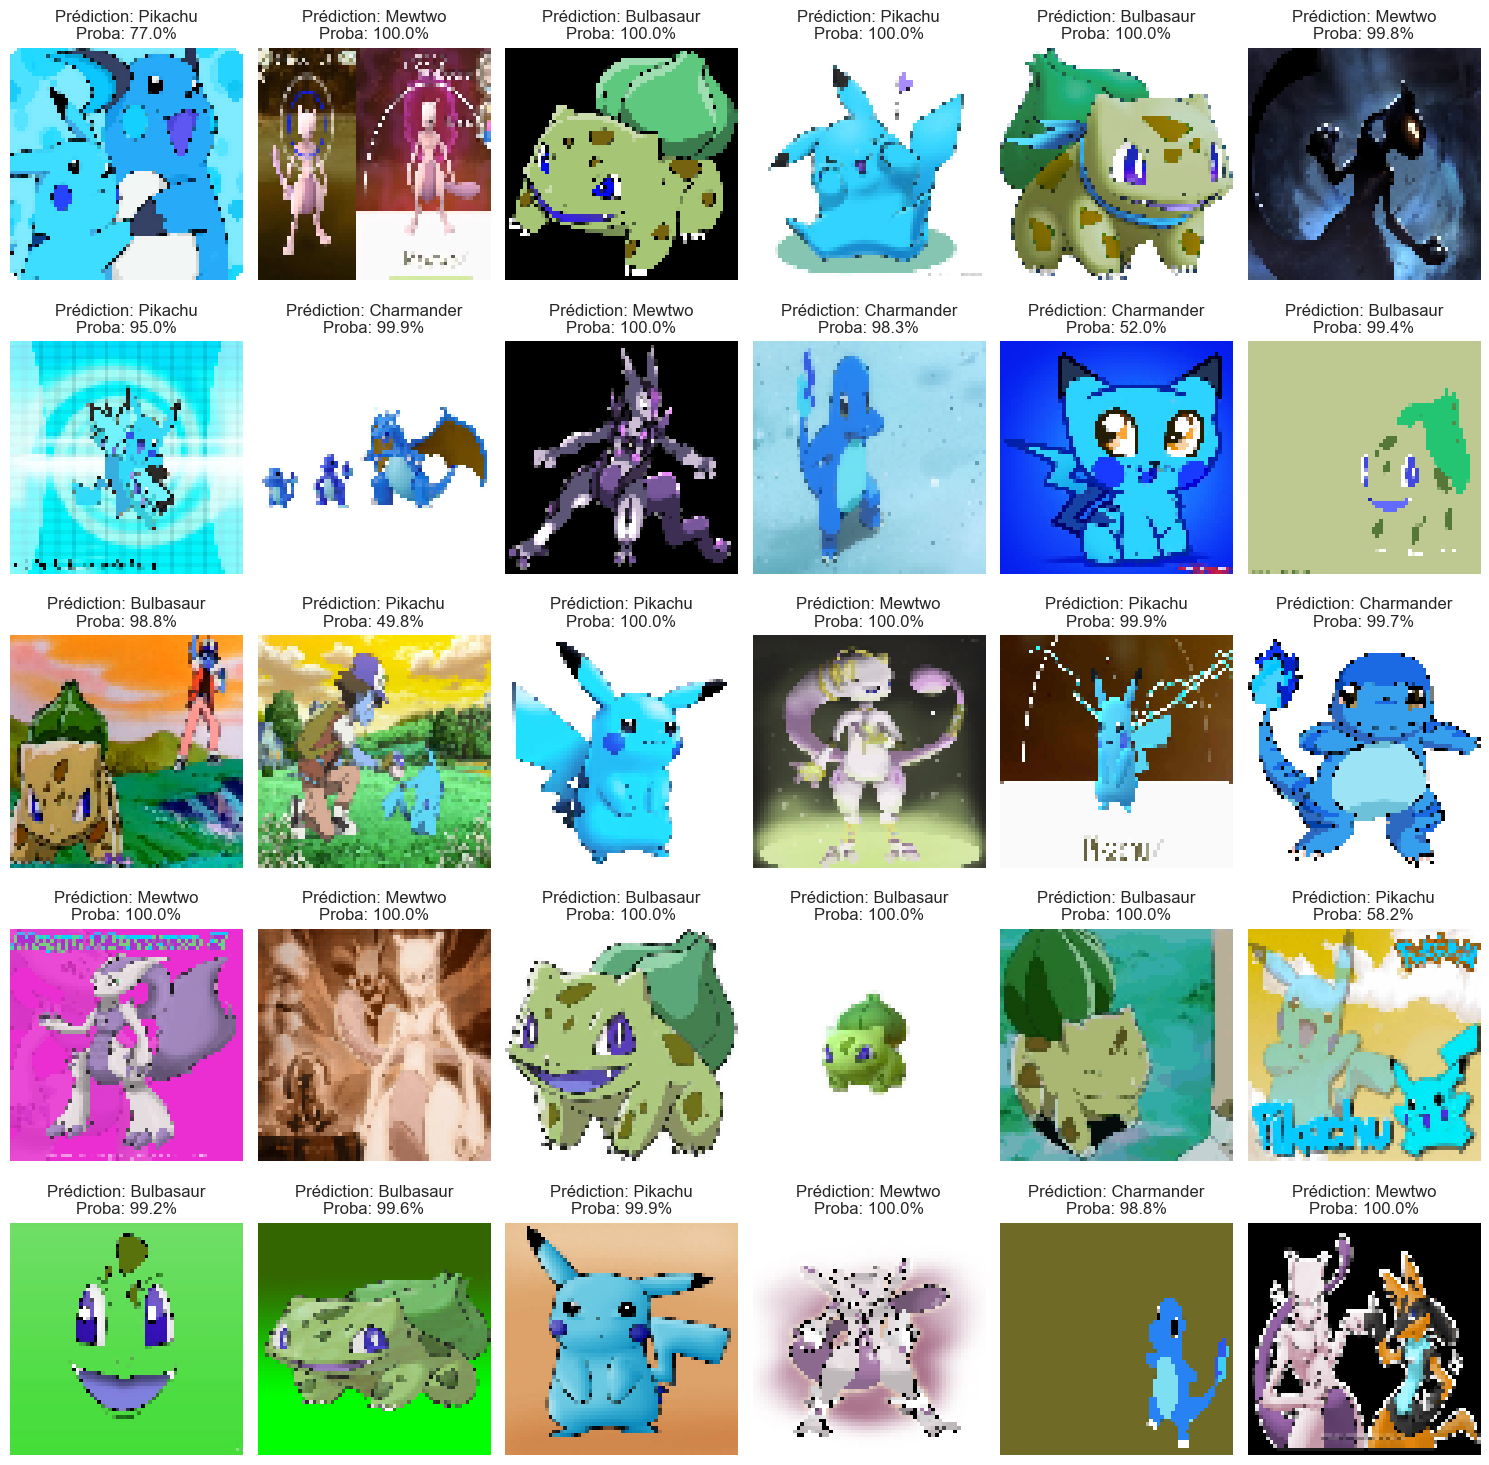

In [59]:
# Chargement des images de test
import matplotlib.pyplot as plt
import numpy as np

# Sélectionner 30 indices aléatoires uniques
indices_aleatoires = np.random.choice(len(X_test), size=30, replace=False)

# Récupérer les images correspondantes
images_test = X_test[indices_aleatoires]

# Définir le mapping des classes
class_mapping = {i: name for i, name in enumerate(classes_four_best)}

# Création de la grille d'affichage
fig = plt.figure(figsize=(15, 15))
rows, cols = 5, 6

for idx, img in enumerate(images_test):
    try:
        # Prédiction
        img_pred = img.reshape(-1, 64, 64, 3)
        pred = model_1.predict(img_pred, verbose=0)
        classe_predite = np.argmax(pred[0])
        pokemon_predit = class_mapping[classe_predite]
        proba = np.max(pred[0]) * 100

        # Affichage
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(f'Prédiction: {pokemon_predit}\nProba: {proba:.1f}%')
        plt.axis('off')

    except Exception as e:
        print(f"Erreur lors du traitement de l'image {idx}: {str(e)}")
        continue

plt.tight_layout()
plt.show()


# Conclusion : Ce que vous avez appris aujourd'hui ! 🎓🚀

## 1. Introduction au Deep Learning et CNN 🧠
- Compréhension de l'early stopping et de l'overfitting 📊
- Indicateurs de performance et matrices de confusion 📈
- Interprétation du R² et des métriques d'évaluation 🎯

## 2. Traitement d'Images 🖼️
- Structure d'une image numérique (RGB) 🎨
- Compréhension des pixels et des canaux de couleur 🌈
- Manipulation des données d'images en Python 🐍

## 3. Architecture CNN 🤖
### Composants principaux d'un CNN :
- Couches de convolution 🔄
- Kernels et filtres 🎯
- Pooling layers 📉
- Flatten et couches denses 📊
- Compréhension du processus de convolution 🔍

## 4. Application Pratique 💪
- Classification d'images de Pokémon 🎮
- Data augmentation et prétraitement d'images 🔄
- Construction et entraînement d'un modèle CNN 🛠️
- Évaluation des performances du modèle 📊

## 5. Bonnes Pratiques en Deep Learning 💡
- Gestion du surapprentissage 🎯
- Optimisation des hyperparamètres 🔧
- Visualisation des résultats 📈
- Préparation des données pour le CNN 🤖



> N'oubliez pas : la qualité de votre modèle dépend de la qualité de vos données et de votre compréhension de l'architecture ! 🌟

> Continuez à pratiquer et à expérimenter avec différentes architectures CNN pour améliorer vos compétences en deep learning ! 🚀